In [33]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

In [34]:
class GreetState(BaseModel):
    message : str = ""

In [35]:
graph = StateGraph(GreetState)

## Nodes - Python Functions 

In [36]:
def Greet(state : GreetState):
    state.message = f"{state.message} ! All Good !"
    return state 

def upperCase(state : GreetState):
    state.message = state.message.upper()
    return state

In [37]:
graph.add_node("greet" , Greet)

In [38]:
graph.add_node("upper_case", upperCase)

In [39]:
graph.add_edge(START, "greet")
graph.add_edge("greet" , "upper_case")
graph.add_edge("upper_case", END)

In [40]:
finalGraph = graph.compile()

In [41]:
res = finalGraph.invoke({"message": "I love LangGraph"})

In [42]:
res

{'message': 'I LOVE LANGGRAPH ! ALL GOOD !'}

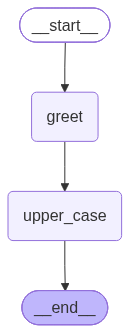

In [43]:
from IPython.display import Image
Image(finalGraph.get_graph().draw_mermaid_png())